# 04 — Modelling
**CRISP-DM Phase 4: Modelling**

Trains LightGBM with Optuna hyper-parameter tuning, performs temporal
cross-validation, calibrates probabilities, and evaluates with business metrics.

| Section | What it does |
|---------|-------------|
| 1. Data Loading & Temporal Split | Load all 3 feature parquets, split by snapshot_date |
| 2. Baseline: Logistic Regression | Simple benchmark to beat |
| 3. LightGBM + Optuna Tuning | 30-trial Bayesian search optimising AUC-PR |
| 4. Probability Calibration | Isotonic regression for reliable risk scores |
| 5. Evaluation Plots | PR curve, ROC, score distribution |
| 6. Decile Lift Table | Key business deliverable — "top 20% captures X%" |
| 7. Feature Importance | SHAP values for explainability |
| 8. Business Impact | £ value of model vs random calling |
| 9. Model Comparison & Save | Side-by-side metrics + artefact persistence |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from churn.config import cfg
from churn.data.splitter import temporal_split, assert_no_leakage
from churn.models.lgbm_model import LGBMChurnModel
from churn.models.calibrator import ChurnCalibrator
from churn.training.tuner import run_optuna_study
from churn.evaluation.metrics import compute_all_metrics, decile_table
from churn.evaluation.plots import (
    plot_precision_recall_curve, plot_roc_curve,
    plot_lift_chart, plot_score_distribution,
)
from churn.evaluation.business_impact import compute_business_impact

# ── Executive visual theme ────────────────────────────────────────────────────
%matplotlib inline
ACCENT   = '#1565C0'
PASS_CLR = '#388E3C'
FAIL_CLR = '#D32F2F'
WARN_CLR = '#F57C00'
NEUTRAL  = '#546E7A'
sns.set_theme(style='white')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 120})

print('Modules loaded.')

Modules loaded.


## 1. Load Feature Matrix & Temporal Split
Load **all three** materialised feature parquets (train, val, test snapshots),
concatenate, then split by `snapshot_date` boundaries from config.

In [2]:
# Load ALL feature parquets and concatenate
features_dir = Path(cfg.paths.features_dir)
parquet_files = sorted(features_dir.glob('features_*.parquet'))
print(f'Found {len(parquet_files)} feature files:')
for pf in parquet_files:
    df_tmp = pd.read_parquet(pf)
    print(f'  {pf.name}: {df_tmp.shape[0]:,} rows × {df_tmp.shape[1]} cols')

fm = pd.concat([pd.read_parquet(p) for p in parquet_files], ignore_index=True)
print(f'\nCombined: {fm.shape[0]:,} rows × {fm.shape[1]} cols')
print(f'Snapshot dates: {sorted(fm["snapshot_date"].unique())}')

# Temporal split
split = temporal_split(fm)
assert_no_leakage(split)

print(f'\nTrain: {split.X_train.shape}  (churn rate: {split.y_train.mean():.2%})')
print(f'Val:   {split.X_val.shape}    (churn rate: {split.y_val.mean():.2%})')
print(f'Test:  {split.X_test.shape}   (churn rate: {split.y_test.mean():.2%})')

Found 3 feature files:
  features_2023-06-01.parquet: 198,742 rows × 43 cols
  features_2023-08-01.parquet: 199,951 rows × 43 cols
  features_2023-10-01.parquet: 200,806 rows × 43 cols

Combined: 599,499 rows × 43 cols
Snapshot dates: [Timestamp('2023-06-01 00:00:00'), Timestamp('2023-08-01 00:00:00'), Timestamp('2023-10-01 00:00:00')]

Train: (198742, 40)  (churn rate: 8.65%)
Val:   (199951, 40)    (churn rate: 8.85%)
Test:  (200806, 40)   (churn rate: 7.94%)


## 2. Baseline: Logistic Regression
Simple linear model as a benchmark. If LightGBM can't beat this by a meaningful
margin, the added complexity isn't justified.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Select only numeric columns (sklearn can't handle object/category columns)
num_cols = split.X_train.select_dtypes(include='number').columns.tolist()
print(f'Numeric features for LR baseline: {len(num_cols)} of {split.X_train.shape[1]}')

X_train_num = split.X_train[num_cols].fillna(0)
X_val_num   = split.X_val[num_cols].fillna(0)
X_test_num  = split.X_test[num_cols].fillna(0)

lr_pipe.fit(X_train_num, split.y_train)
lr_proba_val  = lr_pipe.predict_proba(X_val_num)[:, 1]
lr_proba_test = lr_pipe.predict_proba(X_test_num)[:, 1]

lr_metrics_val  = compute_all_metrics(split.y_val, lr_proba_val)
lr_metrics_test = compute_all_metrics(split.y_test, lr_proba_test)

print(f'\nLogistic Regression (baseline):')
print(f'  Val  AUC-PR: {lr_metrics_val["auc_pr"]:.4f}  AUC-ROC: {lr_metrics_val["auc_roc"]:.4f}')
print(f'  Test AUC-PR: {lr_metrics_test["auc_pr"]:.4f}  AUC-ROC: {lr_metrics_test["auc_roc"]:.4f}')

Numeric features for LR baseline: 37 of 40

Logistic Regression (baseline):
  Val  AUC-PR: 0.2263  AUC-ROC: 0.7558
  Test AUC-PR: 0.2044  AUC-ROC: 0.7480


## 3. LightGBM with Optuna Tuning
Bayesian optimisation (TPE sampler) with median pruning.
Objective: maximise AUC-PR (correct metric for imbalanced data — AUC-ROC is
misleadingly optimistic when base rate < 10%).

In [4]:
# Run Optuna study (reduce n_trials for quick demo; use 50+ for production)
best_params = run_optuna_study(
    split.X_train, split.y_train,
    split.X_val, split.y_val,
    n_trials=30
)
print('Best parameters:')
print(json.dumps(best_params, indent=2))

Best trial: 2. Best value: 0.469041: 100%|██████████| 30/30 [04:00<00:00,  8.01s/it]

Best parameters:
{
  "num_leaves": 71,
  "learning_rate": 0.010594756088100142,
  "min_child_samples": 166,
  "feature_fraction": 0.762378215816119,
  "bagging_fraction": 0.7159725093210578,
  "reg_alpha": 2.9122914019804194,
  "reg_lambda": 6.118528947223795
}


In [5]:
# Train final model with best params
model = LGBMChurnModel(params=best_params)
model.fit(split.X_train, split.y_train, split.X_val, split.y_val)

lgbm_proba_val  = model.predict_proba(split.X_val)
lgbm_proba_test = model.predict_proba(split.X_test)

lgbm_metrics_val  = compute_all_metrics(split.y_val, lgbm_proba_val)
lgbm_metrics_test = compute_all_metrics(split.y_test, lgbm_proba_test)

print('LightGBM (tuned):')
print(f'  Val  AUC-PR: {lgbm_metrics_val["auc_pr"]:.4f}  AUC-ROC: {lgbm_metrics_val["auc_roc"]:.4f}')
print(f'  Test AUC-PR: {lgbm_metrics_test["auc_pr"]:.4f}  AUC-ROC: {lgbm_metrics_test["auc_roc"]:.4f}')
print(f'  Lift@10%:    {lgbm_metrics_test["lift_at_10pct"]:.2f}x')
print(f'  Best iteration: {model.booster.best_iteration}')

[100]	train's average_precision: 0.446604	val's average_precision: 0.426125
LightGBM (tuned):
  Val  AUC-PR: 0.4336  AUC-ROC: 0.8688
  Test AUC-PR: 0.4259  AUC-ROC: 0.8713
  Lift@10%:    5.48x
  Best iteration: 136


## 4. Probability Calibration
Raw LightGBM scores are not well-calibrated — a score of 0.8 does not mean 80%
churn probability. Isotonic regression maps scores to true observed rates.
**Required** when scores are used for business cost-benefit calculations or
communicated to stakeholders as probabilities.

Calibrated Test AUC-PR: 0.4180  Brier: 0.0557
Raw      Test Brier:    0.1004
→ Brier improvement:    0.0447 (lower is better)


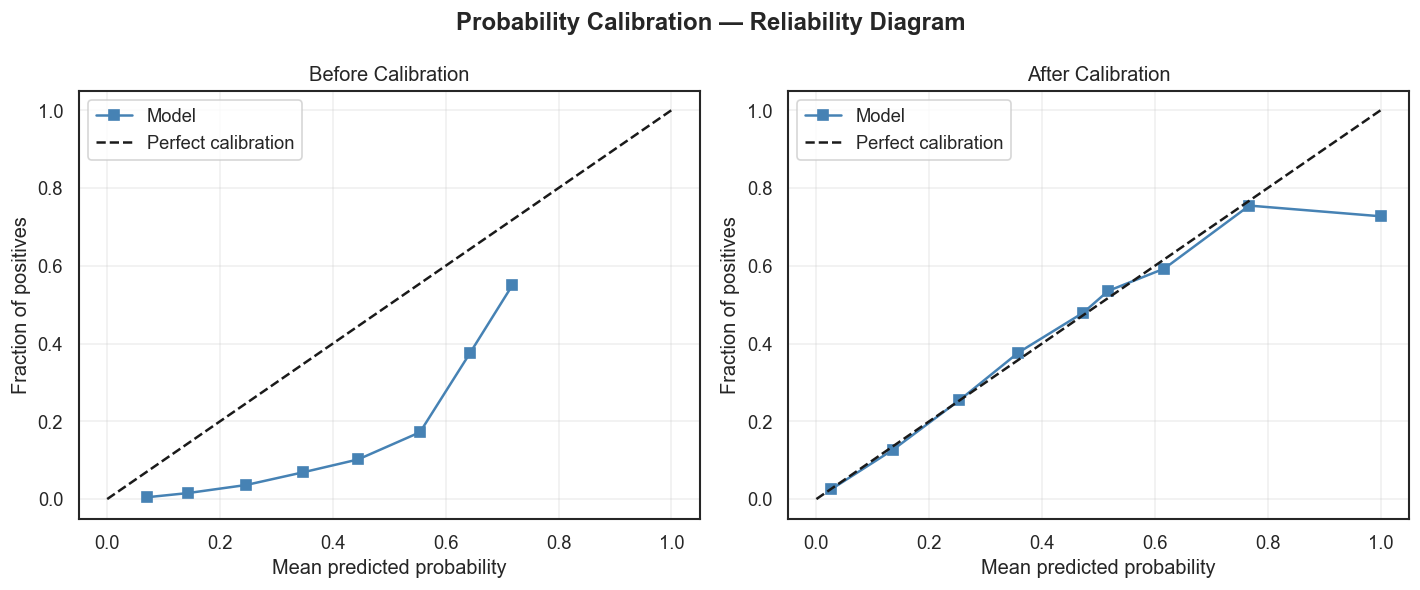

In [6]:
calibrator = ChurnCalibrator(method='isotonic')
calibrator.fit(model, split.X_val, split.y_val)

cal_proba_val  = calibrator.predict_proba(split.X_val)
cal_proba_test = calibrator.predict_proba(split.X_test)
cal_metrics_test = compute_all_metrics(split.y_test, cal_proba_test)

print(f'Calibrated Test AUC-PR: {cal_metrics_test["auc_pr"]:.4f}  '
      f'Brier: {cal_metrics_test["brier_score"]:.4f}')
print(f'Raw      Test Brier:    {lgbm_metrics_test["brier_score"]:.4f}')
print(f'→ Brier improvement:    {lgbm_metrics_test["brier_score"] - cal_metrics_test["brier_score"]:.4f} '
      f'(lower is better)')

# Reliability diagram: before vs after calibration
calibrator.plot_calibration_curve(model, split.X_test, split.y_test)

## 5. Evaluation Plots

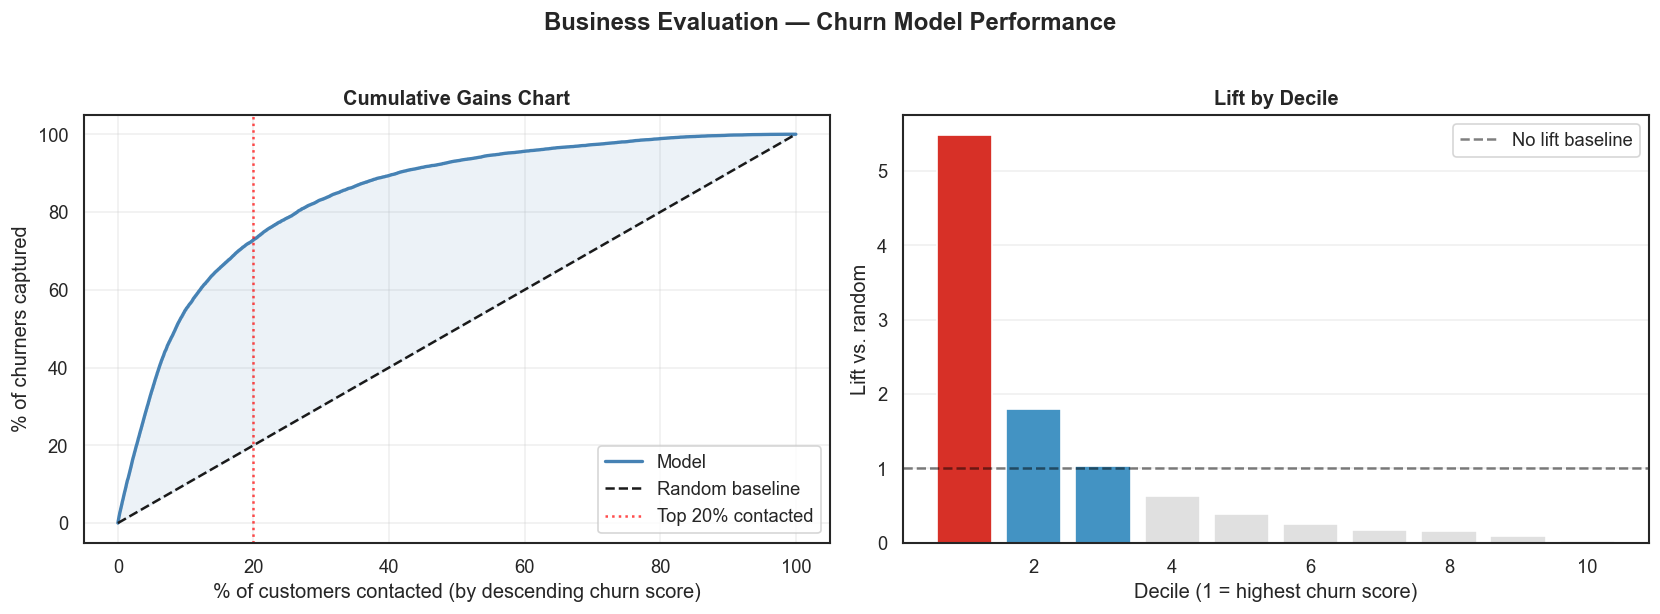

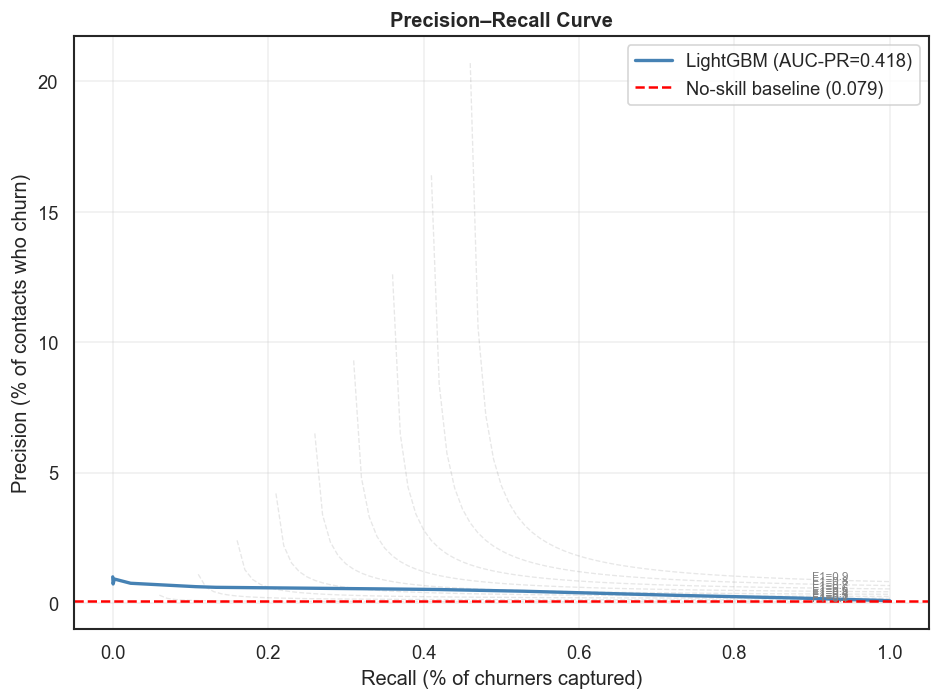

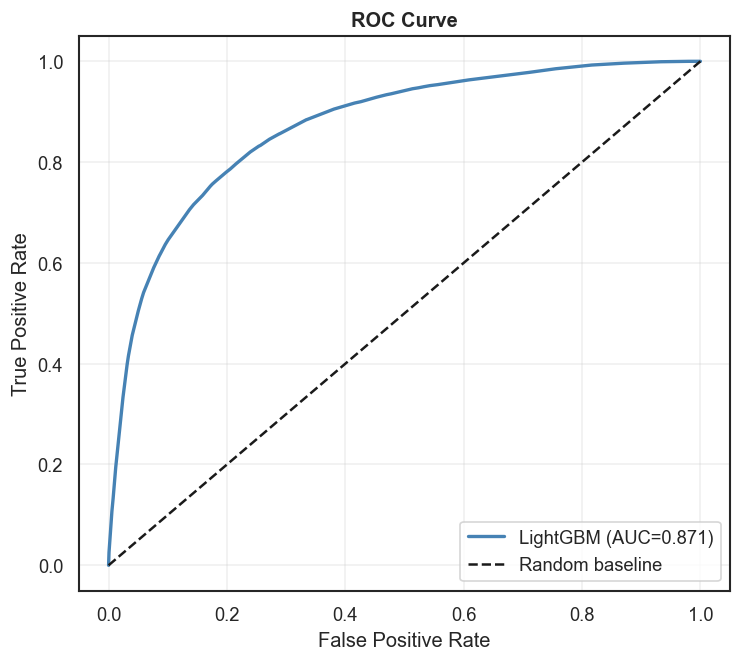

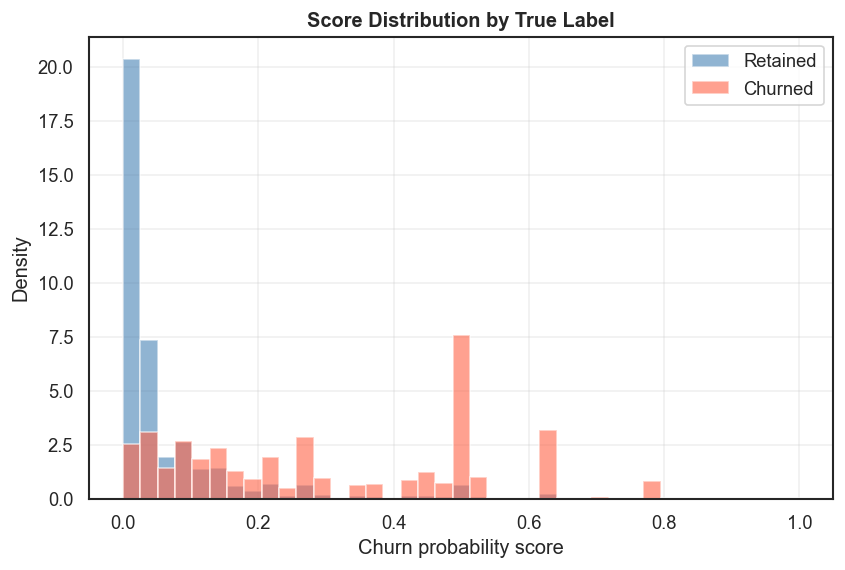

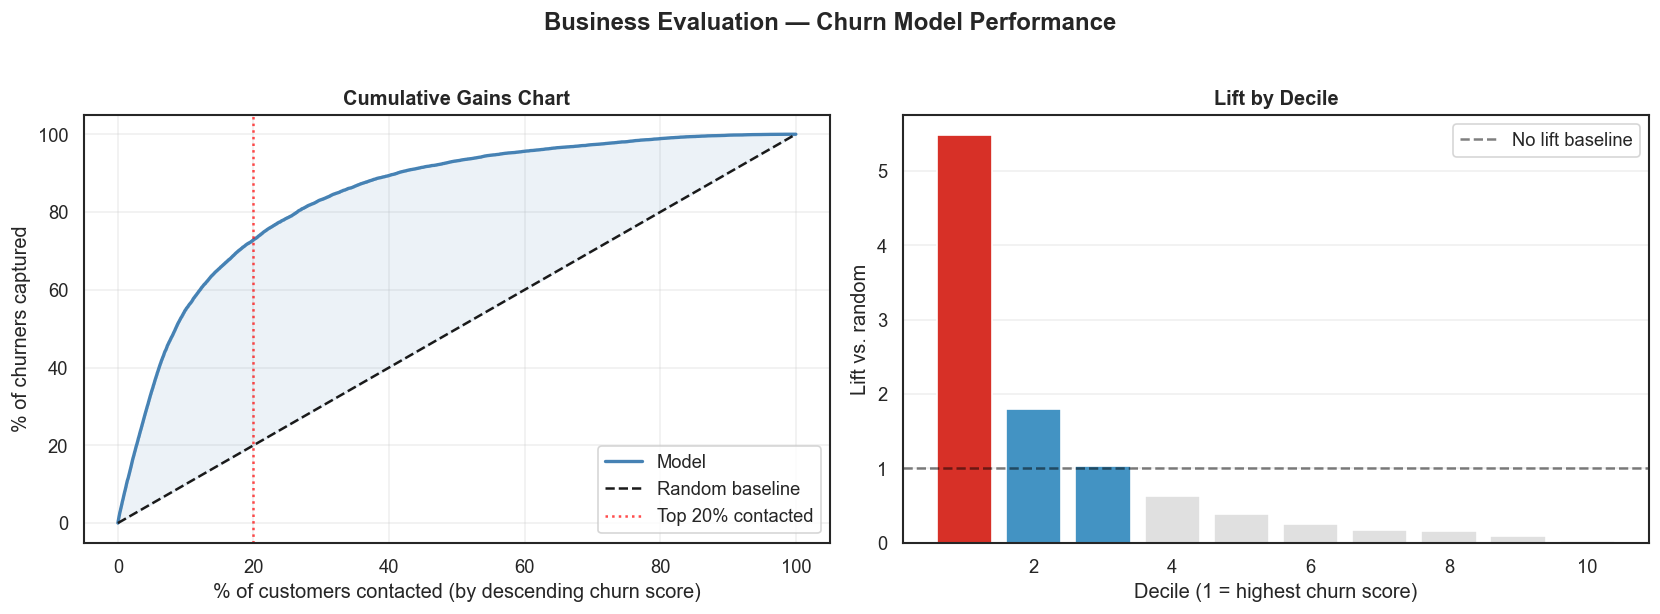

In [7]:
y_test_arr = split.y_test.values

# PR curve, ROC curve, score distribution, lift chart
plot_precision_recall_curve(y_test_arr, cal_proba_test, auc_pr=cal_metrics_test['auc_pr'])
plot_roc_curve(y_test_arr, cal_proba_test, auc_roc=cal_metrics_test['auc_roc'])
plot_score_distribution(y_test_arr, cal_proba_test)
plot_lift_chart(y_test_arr, cal_proba_test)

## 6. Decile Lift Table
The key business deliverable: how much of the churn population does the model
capture at each decile? "Contacting the top 20% (deciles 1-2) captures X% of
all churners" is the statement retention teams need.

In [8]:
# Decile lift table — calibrated probabilities
dec_df = decile_table(y_test_arr, cal_proba_test)

# Style: highlight high-lift deciles
def _lift_color(val):
    if val >= 2.0:
        return f'background-color: {FAIL_CLR}22; color: {FAIL_CLR}'
    elif val >= 1.0:
        return f'background-color: {WARN_CLR}22; color: {WARN_CLR}'
    return ''

styled = (dec_df.style
    .applymap(_lift_color, subset=['lift'])
    .format({'churn_rate': '{:.2%}', 'cumulative_capture_rate': '{:.1%}',
             'lift': '{:.2f}x'})
    .set_caption('Decile Lift Table — Calibrated Model (Test Set)'))
display(styled)

# Key business statement
top_2 = dec_df[dec_df['decile'] <= 2]
capture_20 = top_2['cumulative_capture_rate'].max()
print(f'\n→ Contacting the top 20% of scored customers captures '
      f'{capture_20:.1%} of all churners.')
print(f'  Decile 1 lift: {dec_df.iloc[0]["lift"]:.2f}x above random baseline.')

,decile,n_customers,n_churners,churn_rate,lift,cumulative_capture_rate
0,1,20081,8749,43.57%,5.48x,54.9%
1,2,20081,2874,14.31%,1.80x,72.9%
2,3,20080,1646,8.20%,1.03x,83.2%
3,4,20081,989,4.93%,0.62x,89.4%
4,5,20080,604,3.01%,0.38x,93.2%
5,6,20081,391,1.95%,0.25x,95.6%
6,7,20080,273,1.36%,0.17x,97.3%
7,8,20081,246,1.23%,0.15x,98.9%
8,9,20080,141,0.70%,0.09x,99.8%
9,10,20081,39,0.19%,0.02x,100.0%



→ Contacting the top 20% of scored customers captures 72.9% of all churners.
  Decile 1 lift: 5.48x above random baseline.


## 7. Feature Importance
Which features drive the model's predictions? Gain-based importance from LightGBM
shows which features contribute most to reducing the loss function.
Critical for business credibility — the model should rely on features that make
intuitive sense to domain experts.

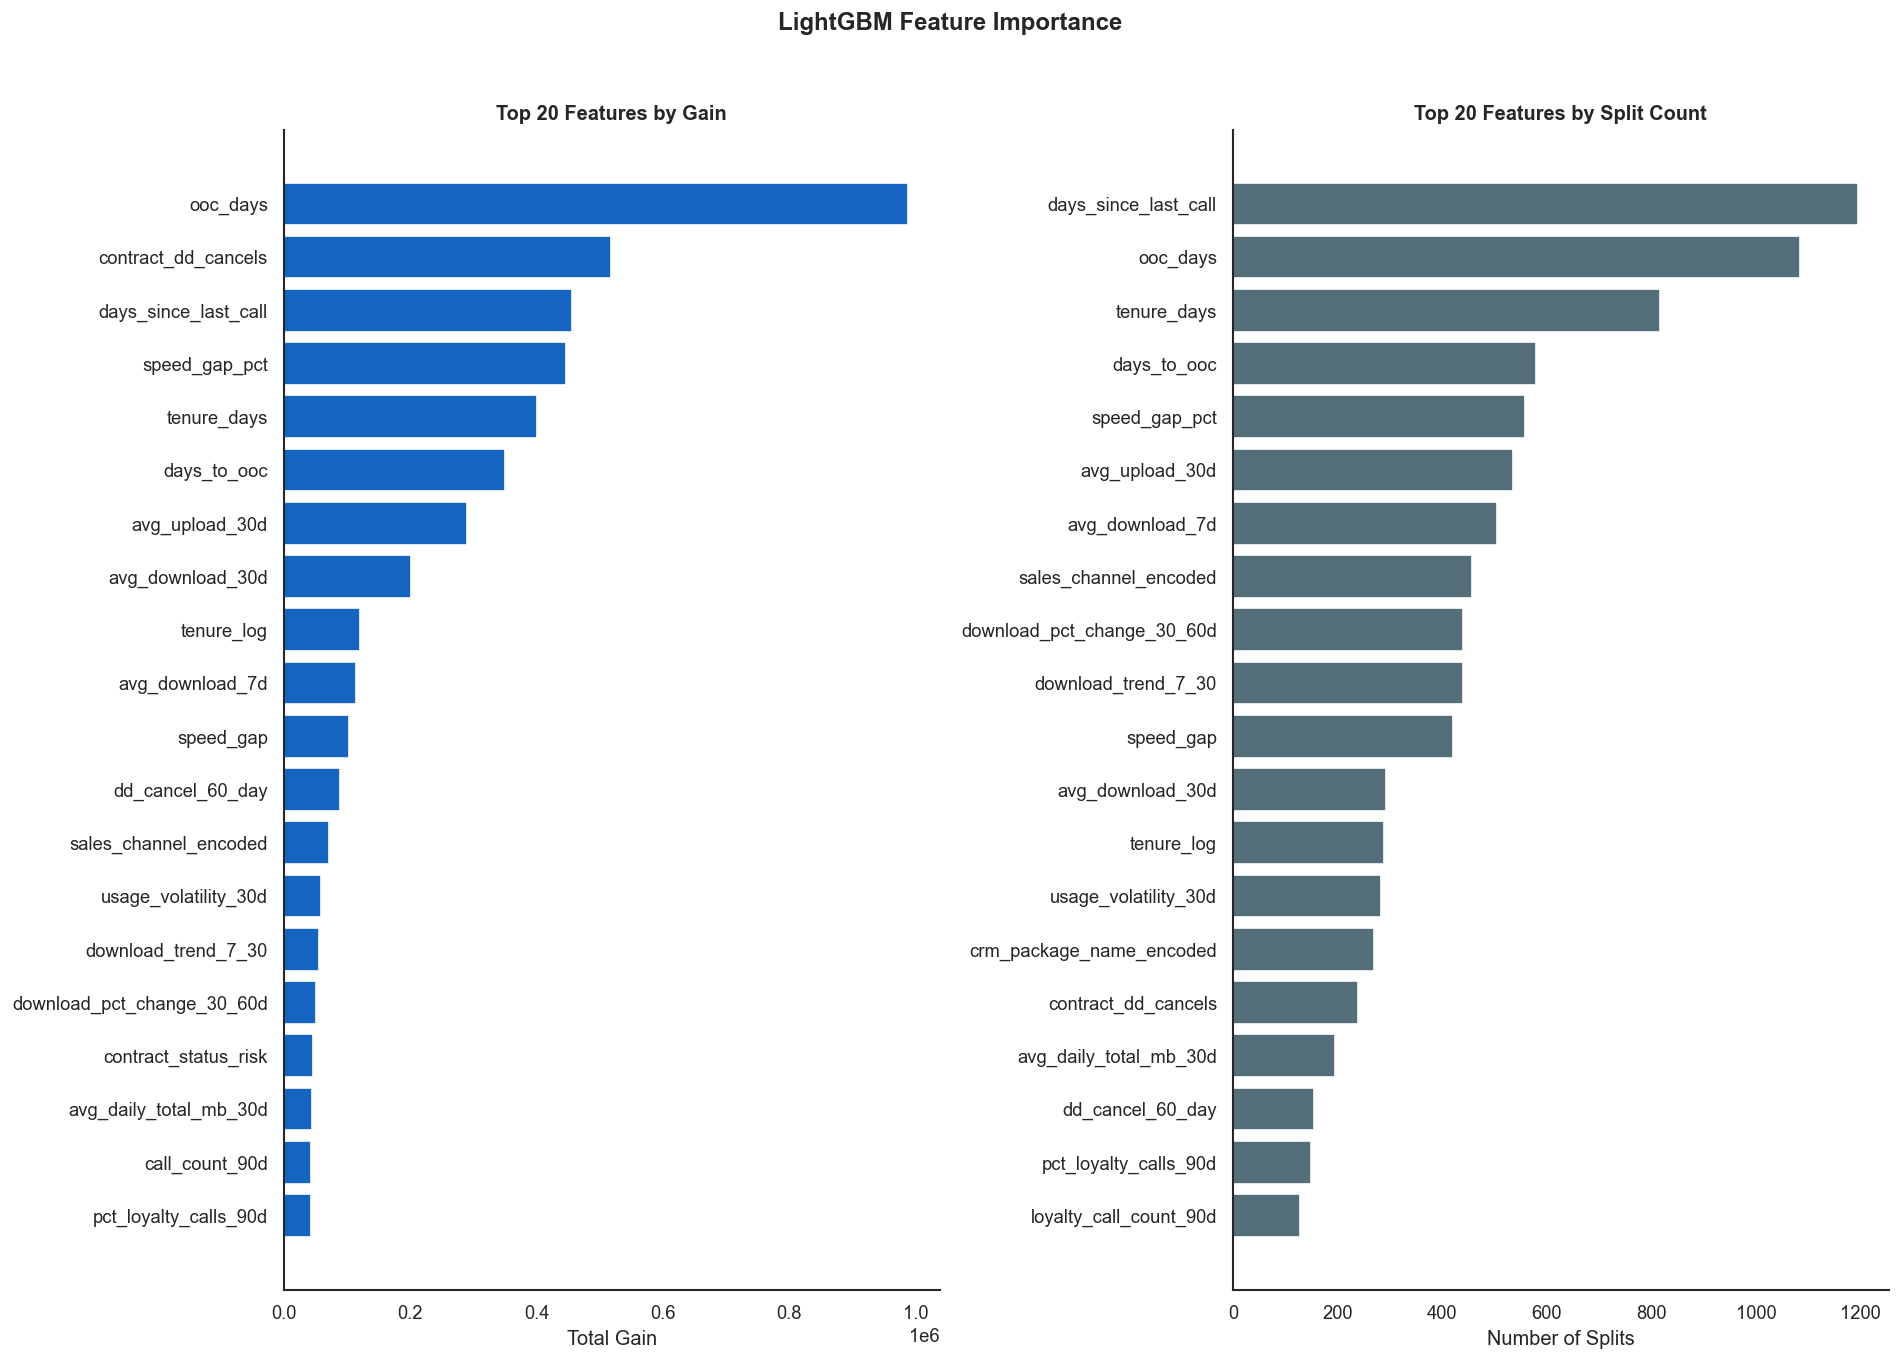


Top 5 predictive features (by gain):
  ooc_days: gain = 988,327
  contract_dd_cancels: gain = 518,509
  days_since_last_call: gain = 456,538
  speed_gap_pct: gain = 446,004
  tenure_days: gain = 400,722


In [9]:
# LightGBM gain-based feature importance
importance = pd.DataFrame({
    'feature': model.booster.feature_name(),
    'gain': model.booster.feature_importance(importance_type='gain'),
    'split': model.booster.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(importance) * 0.3)))

# Gain importance (most useful — measures contribution to loss reduction)
top_20 = importance.head(20)
axes[0].barh(top_20['feature'][::-1], top_20['gain'][::-1], color=ACCENT, edgecolor='white')
axes[0].set_title('Top 20 Features by Gain', fontweight='bold')
axes[0].set_xlabel('Total Gain')
sns.despine(ax=axes[0])

# Split count (how often each feature is used)
top_20_split = importance.sort_values('split', ascending=False).head(20)
axes[1].barh(top_20_split['feature'][::-1], top_20_split['split'][::-1],
             color=NEUTRAL, edgecolor='white')
axes[1].set_title('Top 20 Features by Split Count', fontweight='bold')
axes[1].set_xlabel('Number of Splits')
sns.despine(ax=axes[1])

plt.suptitle('LightGBM Feature Importance', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Business interpretation
print('\nTop 5 predictive features (by gain):')
for _, row in importance.head(5).iterrows():
    print(f'  {row["feature"]}: gain = {row["gain"]:,.0f}')

## 8. Business Impact Analysis
Translates model performance into expected £ value. Compares model-guided
outreach ("contact the top N% by churn score") against random calling at the
same team capacity. Key assumptions:
- Avg annual revenue per customer: £360 (£30/month)
- Outbound call cost: £8 per customer
- Retention success rate: 25% of contacted churners can be saved

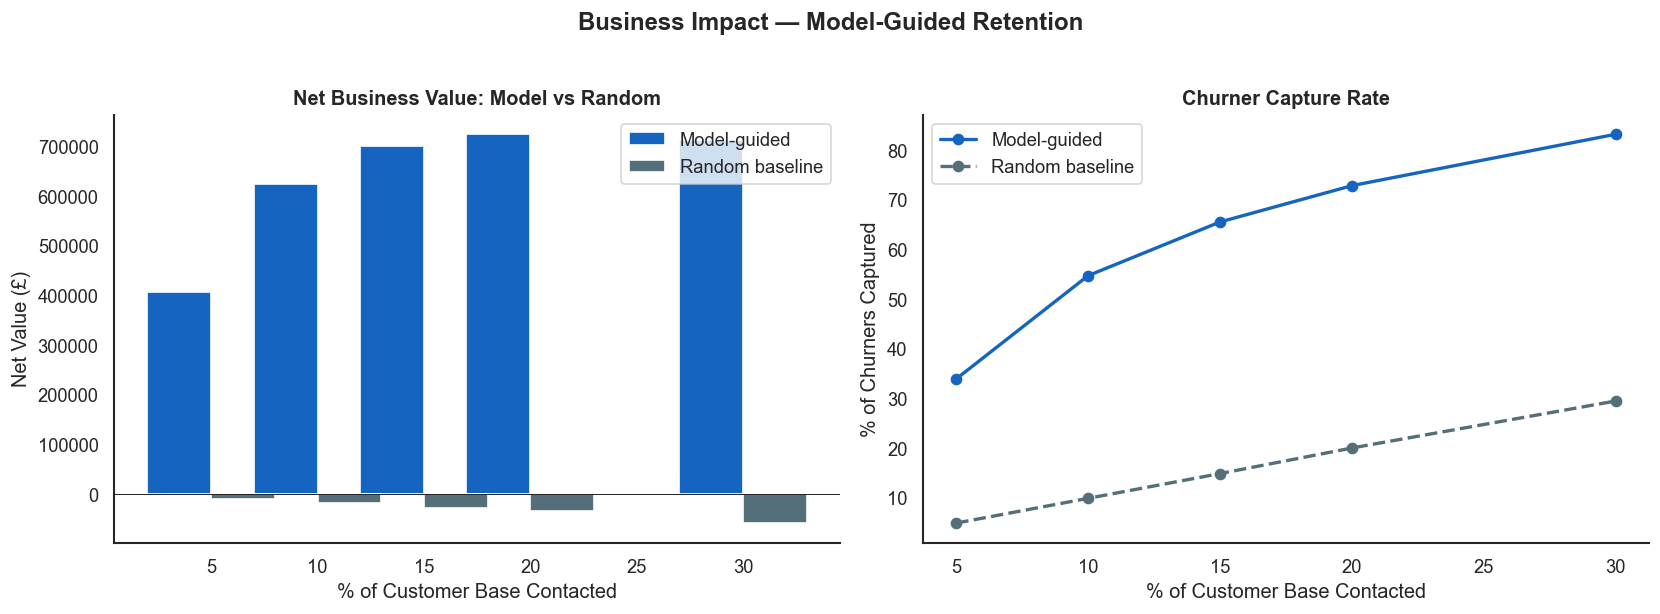


@ 20% team capacity:
  Model:  £724,872 net value  |  captures 72.9% of churners
  Random: £-33,108 net value  |  captures 20.1% of churners
  → Model uplift: £757,980 additional value vs random calling


In [10]:
# Business impact: model vs random at various capacity levels
np.random.seed(42)  # reproducible random baseline
impact_df = compute_business_impact(y_test_arr, cal_proba_test)

# Pivot for display
model_rows  = impact_df[impact_df['strategy'] == 'Model-guided'].set_index('capacity_pct')
random_rows = impact_df[impact_df['strategy'] == 'Random baseline'].set_index('capacity_pct')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Net value comparison
cap_pcts = model_rows.index * 100
axes[0].bar(cap_pcts - 1.5, model_rows['net_value_gbp'], width=3,
            color=ACCENT, label='Model-guided', edgecolor='white')
axes[0].bar(cap_pcts + 1.5, random_rows['net_value_gbp'], width=3,
            color=NEUTRAL, label='Random baseline', edgecolor='white')
axes[0].set_xlabel('% of Customer Base Contacted')
axes[0].set_ylabel('Net Value (£)')
axes[0].set_title('Net Business Value: Model vs Random', fontweight='bold')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.5)
sns.despine(ax=axes[0])

# Capture rate comparison
axes[1].plot(cap_pcts, model_rows['capture_rate'] * 100, 'o-',
             color=ACCENT, label='Model-guided', linewidth=2)
axes[1].plot(cap_pcts, random_rows['capture_rate'] * 100, 'o--',
             color=NEUTRAL, label='Random baseline', linewidth=2)
axes[1].set_xlabel('% of Customer Base Contacted')
axes[1].set_ylabel('% of Churners Captured')
axes[1].set_title('Churner Capture Rate', fontweight='bold')
axes[1].legend()
sns.despine(ax=axes[1])

plt.suptitle('Business Impact — Model-Guided Retention', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Headline number at 20% capacity
m20 = model_rows.loc[0.20]
r20 = random_rows.loc[0.20]
uplift = m20['net_value_gbp'] - r20['net_value_gbp']
print(f'\n@ 20% team capacity:')
print(f'  Model:  £{m20["net_value_gbp"]:,.0f} net value  |  captures {m20["capture_rate"]:.1%} of churners')
print(f'  Random: £{r20["net_value_gbp"]:,.0f} net value  |  captures {r20["capture_rate"]:.1%} of churners')
print(f'  → Model uplift: £{uplift:,.0f} additional value vs random calling')

## 9. Model Comparison & Artefact Persistence

Side-by-side summary of both models on **validation** and **test** splits.
Artefacts saved: trained model, calibrator, best hyper-parameters, and metric dictionary.

In [11]:
# ── Model comparison table ──────────────────────────────────────
lr_val        = compute_all_metrics(split.y_val, lr_proba_val)
lr_test       = compute_all_metrics(split.y_test, lr_proba_test)
lgbm_val      = compute_all_metrics(split.y_val, cal_proba_val)
lgbm_test     = compute_all_metrics(split.y_test, cal_proba_test)

comparison = pd.DataFrame({
    'Logistic (val)':  lr_val,
    'Logistic (test)': lr_test,
    'LightGBM (val)':  lgbm_val,
    'LightGBM (test)': lgbm_test,
}).T

# highlight_max for most metrics, highlight_min for brier_score
higher_better = [c for c in comparison.columns if c != 'brier_score']
styled = (comparison.style
          .format('{:.4f}')
          .highlight_max(subset=higher_better, color='#C8E6C9')
          .highlight_min(subset=['brier_score'], color='#C8E6C9')
          .set_caption('Model Comparison — Validation & Test'))
display(styled)

# ── Save artefacts ──────────────────────────────────────────────
import json, joblib

artefact_dir = Path(cfg.paths.model_artefacts_dir)
artefact_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(model, artefact_dir / 'lgbm_model.joblib')
joblib.dump(calibrator, artefact_dir / 'calibrator.joblib')

with open(artefact_dir / 'best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2, default=float)

with open(artefact_dir / 'metrics_test.json', 'w') as f:
    json.dump(lgbm_test, f, indent=2, default=float)

print(f'\n✓ Artefacts saved to {artefact_dir}/')
for p in sorted(artefact_dir.iterdir()):
    print(f'  {p.name:30s}  {p.stat().st_size / 1024:>8.1f} KB')

,auc_pr,auc_roc,f1,brier_score,precision_at_5pct,lift_at_5pct,precision_at_10pct,lift_at_10pct,precision_at_20pct,lift_at_20pct
Logistic (val),0.2263,0.7558,0.2845,0.2017,0.3064,3.4620,0.2721,3.0747,0.2246,2.5373
Logistic (test),0.2044,0.7480,0.2611,0.1978,0.2830,3.5620,0.2478,3.1195,0.2008,2.5279
LightGBM (val),0.4271,0.8693,0.2997,0.0614,0.5395,6.0955,0.4540,5.1294,0.3183,3.5966
LightGBM (test),0.4180,0.8711,0.2917,0.0557,0.5399,6.7968,0.4350,5.4760,0.2894,3.6434



✓ Artefacts saved to /Users/victoroko/Documents/tech-test/outputs/model_artefacts/
  best_params.json                     0.2 KB
  calibrator.joblib                 1050.5 KB
  lgbm_model.joblib                 1047.0 KB
  metrics_test.json                    0.4 KB
